# 01 Working Research

End-to-end research notebook using existing `src` modules.

## 1) Setup

In [1]:
import warnings
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

# Ensure project root is on sys.path so `import src.*` works.
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import load_config

config = load_config()
DATA_DIR = config.data_dir
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', project_root)
print('DATA_DIR:', DATA_DIR)


Project root: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml
DATA_DIR: data


## 2) Fetch data (Alpaca)

### Why Fetch 5 Years of Data

We use a ~5-year fetch window (2021-01-01 to 2026-01-01) to make the research more robust:
- It includes multiple market regimes (trend, drawdown, recovery, range), which reduces overfitting to one period.
- It provides enough candidate trades for walk-forward training/validation/testing splits.
- It stabilizes probability calibration (`p_good`) and threshold/size mapping (e.g., q20/q80).

Tradeoff: data pull and preprocessing are slower, but model and backtest conclusions are more reliable.


In [2]:
from src.data_alpaca import fetch_minute_bars

symbol = "SPY"
start = "2021-01-01"
end = "2026-01-01"   # ~5 years
bars_raw = fetch_minute_bars(symbol=symbol, start=start, end=end, adjustment="raw", force=True)


raw_path = DATA_DIR / 'bars_raw.parquet'
bars_raw.to_parquet(raw_path, index=False)

print('Saved:', raw_path)
print('Rows:', len(bars_raw))
print('Min timestamp:', bars_raw['timestamp'].min() if len(bars_raw) else None)
print('Max timestamp:', bars_raw['timestamp'].max() if len(bars_raw) else None)

bars_raw.head()


Saved: data/bars_raw.parquet
Rows: 1025947
Min timestamp: 2021-01-04 04:00:00-05:00
Max timestamp: 2025-12-31 19:59:00-05:00


,timestamp,open,high,low,close,volume
0,2021-01-04 04:00:00-05:00,375.640000,375.690000,375.640000,375.690000,"2,606.000000"
1,2021-01-04 04:01:00-05:00,375.690000,375.810000,375.690000,375.790000,"16,041.000000"
2,2021-01-04 04:02:00-05:00,375.840000,375.880000,375.790000,375.820000,"12,514.000000"
3,2021-01-04 04:04:00-05:00,375.900000,376.040000,375.900000,375.910000,"8,995.000000"
4,2021-01-04 04:05:00-05:00,375.900000,375.900000,375.880000,375.880000,"4,550.000000"


In [3]:
bars_raw.tail()


,timestamp,open,high,low,close,volume
1025942,2025-12-31 19:54:00-05:00,682.510000,682.519800,682.510000,682.519800,571.000000
1025943,2025-12-31 19:55:00-05:00,682.520000,682.520000,682.500000,682.510000,"1,965.000000"
1025944,2025-12-31 19:56:00-05:00,682.520000,682.520000,682.519700,682.519700,683.000000
1025945,2025-12-31 19:58:00-05:00,682.550000,682.590000,682.550000,682.550000,"1,543.000000"
1025946,2025-12-31 19:59:00-05:00,682.520000,682.590000,682.500000,682.500000,523.000000


## 3) Preprocess

Saved: data/bars_preprocessed.parquet rows= 490705


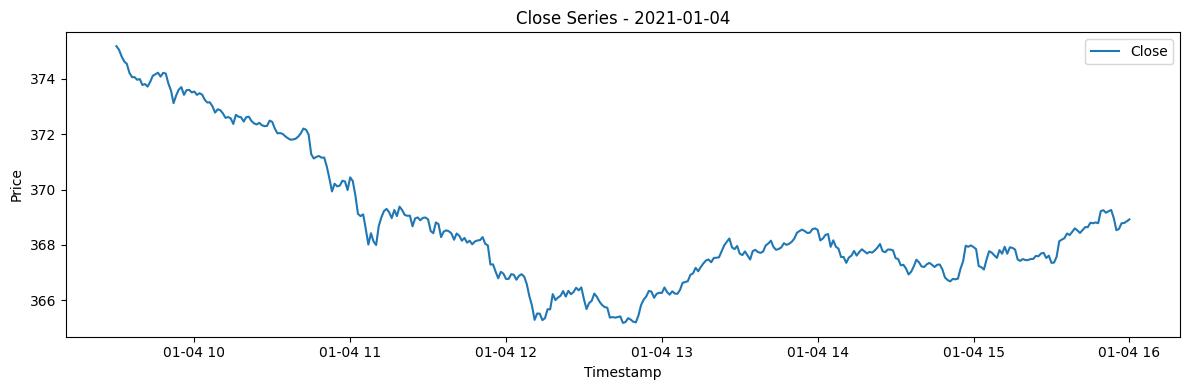

In [4]:
from src.preprocess import preprocess_bars

bars_pre = preprocess_bars(bars_raw)
pre_path = DATA_DIR / 'bars_preprocessed.parquet'
bars_pre.to_parquet(pre_path, index=False)
print('Saved:', pre_path, 'rows=', len(bars_pre))

# Pick first complete day (09:30..16:00 inclusive => 391 rows)
day_counts = bars_pre.groupby('date').size()
complete_days = day_counts[day_counts >= 391].index
sample_day = complete_days[0] if len(complete_days) else bars_pre['date'].iloc[0]

day_df = bars_pre[bars_pre['date'] == sample_day].copy()

plt.figure(figsize=(12, 4))
plt.plot(day_df['timestamp'], day_df['close'], label='Close')
plt.title(f'Close Series - {sample_day}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


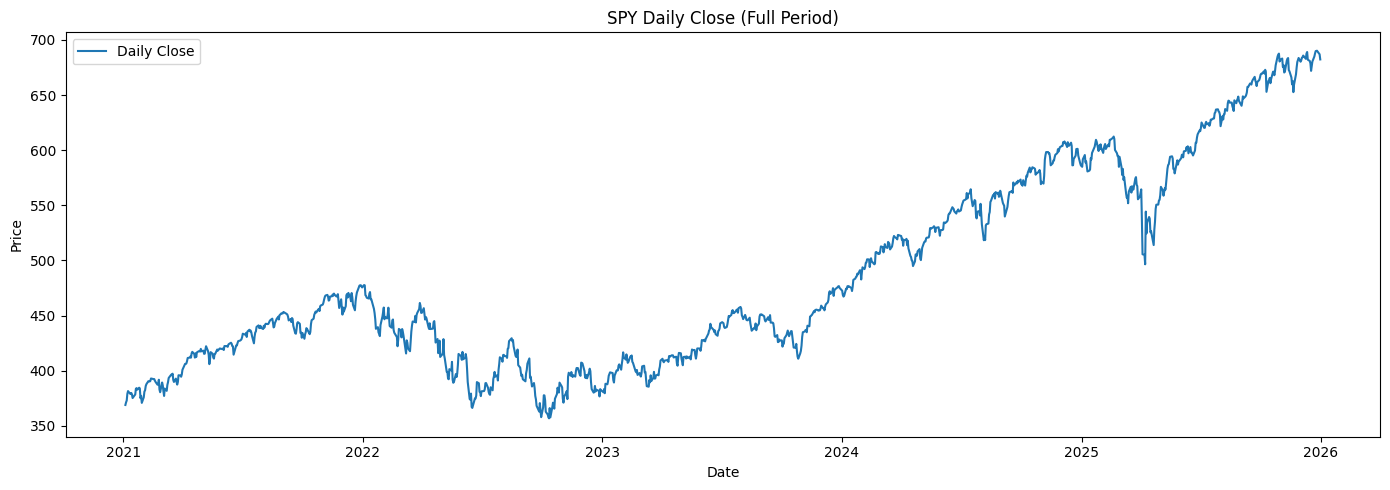

In [5]:
# 1) Full-history daily close (last bar of each day)
daily_close = (
    bars_pre.sort_values("timestamp")
    .groupby("date", as_index=False)["close"]
    .last()
)
daily_close["date"] = pd.to_datetime(daily_close["date"])

plt.figure(figsize=(14, 5))
plt.plot(daily_close["date"], daily_close["close"], label="Daily Close")
plt.title("SPY Daily Close (Full Period)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 4) Indicators (Noise Area + Bands + VWAP)

Saved: data/bars_enriched.parquet rows= 490705


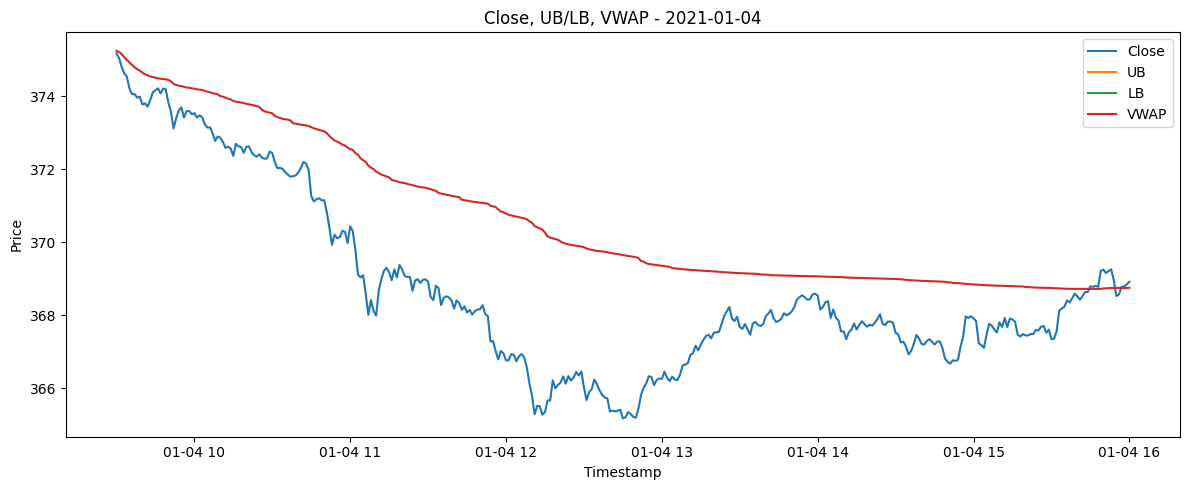

In [6]:
from src.indicators import (
    compute_intraday_move_from_open,
    compute_sigma_profile,
    compute_gap_adjusted_bands,
    compute_vwap,
)

bars_ind = compute_intraday_move_from_open(bars_pre)
bars_ind = compute_sigma_profile(bars_ind, lookback_days=14)
bars_ind = compute_gap_adjusted_bands(bars_ind)
bars_ind = compute_vwap(bars_ind)

enriched_path = DATA_DIR / 'bars_enriched.parquet'
bars_ind.to_parquet(enriched_path, index=False)
print('Saved:', enriched_path, 'rows=', len(bars_ind))

sample = bars_ind[bars_ind['date'] == sample_day].copy()

plt.figure(figsize=(12, 5))
plt.plot(sample['timestamp'], sample['close'], label='Close')
plt.plot(sample['timestamp'], sample['UB'], label='UB')
plt.plot(sample['timestamp'], sample['LB'], label='LB')
plt.plot(sample['timestamp'], sample['VWAP'], label='VWAP')
plt.title(f'Close, UB/LB, VWAP - {sample_day}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


## 5) Baseline backtest (paper strategy)

In [7]:
from src.baseline_strategy import run_baseline_backtest

baseline_out = run_baseline_backtest(bars_ind)
baseline_equity = baseline_out['equity_curve'].copy()
baseline_trades = baseline_out['trades'].copy()
baseline_summary = baseline_out['summary']

# Save outputs like CLI
baseline_equity.to_parquet(DATA_DIR / 'baseline_equity_curve.parquet', index=False)
baseline_trades.to_parquet(DATA_DIR / 'baseline_trades.parquet', index=False)
with open(DATA_DIR / 'baseline_summary.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_summary, f, indent=2, default=str)

pd.DataFrame([baseline_summary]).T.rename(columns={0: 'value'})


,value
sharpe,1.125263
cagr_ish,0.171437
max_drawdown,-0.131538
n_days,"1,255.000000"
final_equity,"219,903.083900"
trades_count,"1,205.000000"
turnover,"6,350.015326"
total_costs,"9,636.282000"


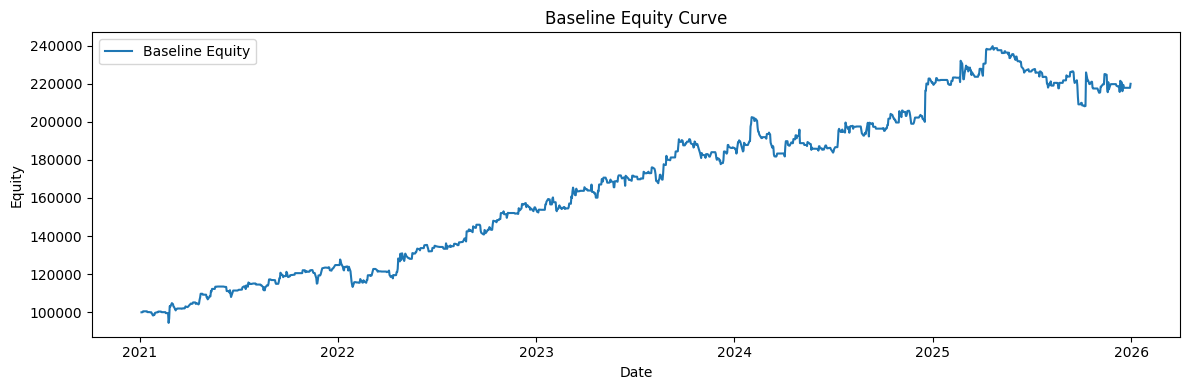

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(baseline_equity['date']), baseline_equity['equity'], label='Baseline Equity')
plt.title('Baseline Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()


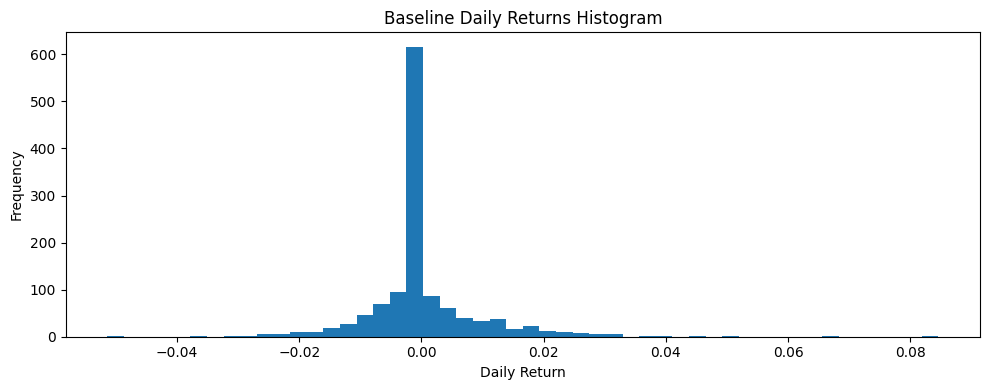

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(baseline_equity['daily_return'].dropna(), bins=50)
plt.title('Baseline Daily Returns Histogram')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [10]:
best_days = baseline_equity.nlargest(20, 'daily_return')[['date', 'daily_return', 'daily_pnl']]
worst_days = baseline_equity.nsmallest(20, 'daily_return')[['date', 'daily_return', 'daily_pnl']]

print('Top 20 best days:')
display(best_days)
print('Top 20 worst days:')
display(worst_days)


Top 20 best days:


,date,daily_return,daily_pnl
1198,2025-10-10,0.084609,"17,619.819000"
996,2024-12-18,0.082062,"16,406.875600"
36,2021-02-25,0.066322,"6,417.716000"
1038,2025-02-21,0.050615,"11,176.531000"
328,2022-04-22,0.044112,"5,419.361000"
773,2024-01-31,0.040260,"7,642.313000"
415,2022-08-26,0.038739,"5,313.651000"
924,2024-09-06,0.037547,"7,219.259000"
227,2021-11-26,0.036074,"4,155.312000"
757,2024-01-08,0.032732,"5,999.796000"


Top 20 worst days:


,date,daily_return,daily_pnl
34,2021-02-23,-0.051439,"-5,121.292000"
836,2024-05-01,-0.036226,"-7,095.088000"
1225,2025-11-18,-0.031204,"-7,009.808000"
1187,2025-09-25,-0.027308,"-5,980.981600"
331,2022-04-27,-0.026013,"-3,401.514900"
923,2024-09-05,-0.025834,"-5,098.912000"
527,2023-02-07,-0.025698,"-4,053.888000"
334,2022-05-02,-0.025439,"-3,332.405000"
267,2022-01-25,-0.025088,"-3,050.112000"
225,2021-11-23,-0.024706,"-2,914.193800"


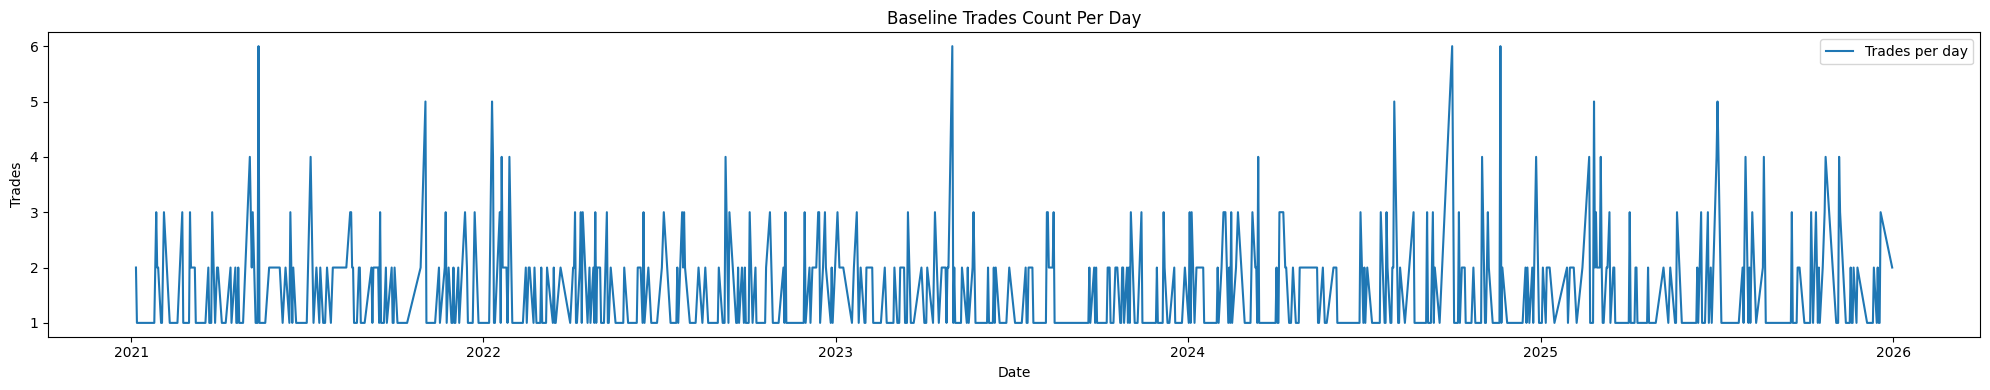

In [11]:
if not baseline_trades.empty:
    trades_per_day = pd.to_datetime(baseline_trades['entry_timestamp']).dt.strftime('%Y-%m-%d').value_counts().sort_index()
else:
    trades_per_day = pd.Series(dtype=int)

plt.figure(figsize=(20, 4))
plt.plot(pd.to_datetime(trades_per_day.index), trades_per_day.values, label='Trades per day')
plt.title('Baseline Trades Count Per Day')
plt.xlabel('Date')
plt.ylabel('Trades')
plt.legend()
plt.tight_layout()
plt.show()


## 6) Build ML dataset (meta-labeling)

In [12]:
from src.features_ml import build_ml_dataset

# Option A (default): baseline_trade label uses realized baseline trade outcome.
# Option B (less noisy target): fixed_horizon label uses next horizon net return.
X, y, meta = build_ml_dataset(
    bars_ind,
    label_mode="fixed_horizon",   # try "baseline_trade" too
    horizon_mins=30,
)

# build_ml_dataset already saves DATA_DIR/ml_dataset.parquet
with open(DATA_DIR / 'ml_dataset_meta.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'rows': int(len(X)),
            'features': list(X.columns),
            'positive_rate': float(y.mean()) if len(y) else 0.0,
        },
        f,
        indent=2,
    )

print('Rows:', len(X))
print('Class balance (mean y):', float(y.mean()) if len(y) else np.nan)
X.head()


Rows: 1205
Class balance (mean y): 0.5427385892116182


,signed_break_distance,break_strength,band_width,vwap_diff,intraday_return,ret_30m,realized_vol_30m,whipsaw_60m,time_of_day_minutes,tod_sin,tod_cos
0,0.001798,0.615084,0.015776,0.005981,0.011839,0.005124,0.000378,3.000000,60,0.822984,0.568065
1,0.000010,0.500319,0.030813,0.005465,0.017568,-0.001128,0.000274,0.000000,240,-0.663123,-0.748511
2,0.000062,0.502589,0.023978,0.003744,0.007843,0.003176,0.000379,0.000000,60,0.822984,0.568065
3,0.001175,0.582050,0.014248,-0.001934,-0.005933,-0.006724,0.000746,0.000000,60,0.822984,0.568065
4,0.000089,0.504356,0.020477,0.003419,0.006848,0.000887,0.000113,0.000000,210,-0.239316,-0.970942


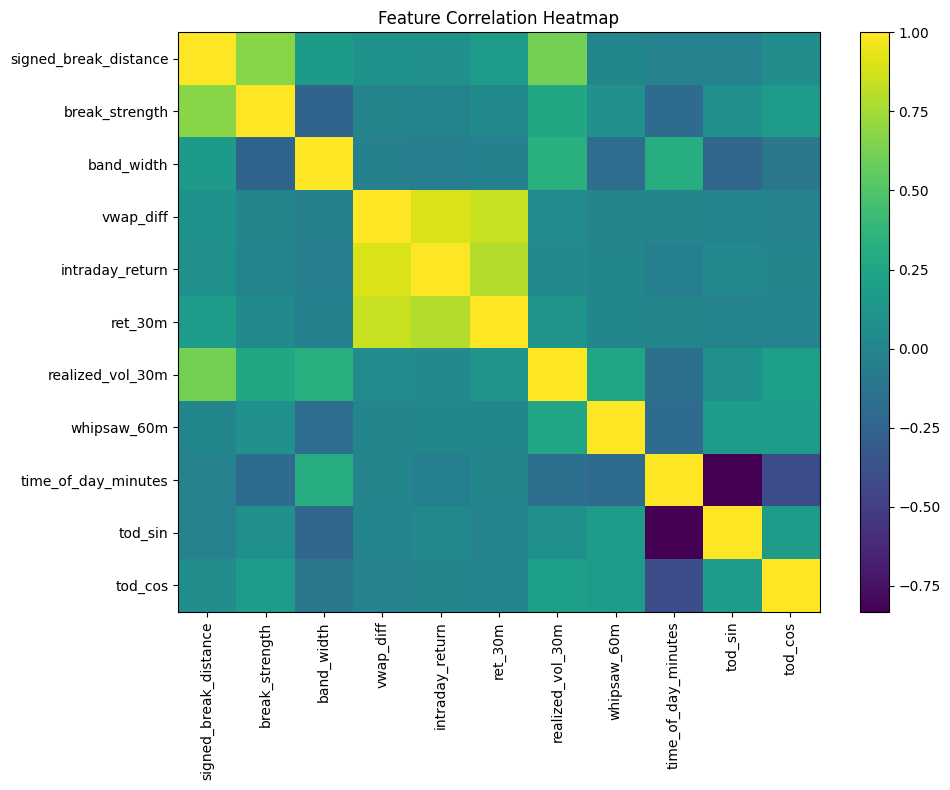

In [13]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr.values, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 7) Train ML (walk-forward)

### 7.1 Train And Load Report

Why this matters: this gives the selected model, chosen threshold/quantiles, and per-split results before any backtest overlay is run.

In [14]:
import importlib
import src.train_ml as train_ml_mod
importlib.reload(train_ml_mod)

# Rolling walk-forward setup: past -> validate -> future test, then roll.
train_out = train_ml_mod.train_walk_forward_models(
    train_months=24,
    val_months=3,
    test_months=3,
    step_months=3,
)
report_path = Path(train_out['report_path'])

with open(report_path, 'r', encoding='utf-8') as f:
    report = json.load(f)

best = report.get('best', {})
print('Best model:', best.get('model_name'))
print('Selected threshold:', best.get('threshold'))
print('q20/q40/q60/q80:', best.get('prob_q20'), best.get('prob_q40'), best.get('prob_q60'), best.get('prob_q80'))
print('Report file:', report_path)


Best model: logistic
Selected threshold: 0.6200000000000001
q20/q40/q60/q80: 0.5639168398927271 0.5764550238790945 0.5865350823943868 0.5996366992868486
Report file: data/models/walk_forward_report.json


### 7.2 Split-Level Classification Metrics

Why this matters: AUC/precision/recall tell whether ranking and directional classification are stable across time splits, not just on one window.

In [15]:
split_rows = []
for split in report.get('splits', []):
    sid = split.get('split_id')
    for model_name, vals in split.get('models', {}).items():
        split_rows.append(
            {
                'split_id': sid,
                'model': model_name,
                'val_auc': vals.get('validation', {}).get('auc'),
                'test_auc': vals.get('test', {}).get('auc'),
                'val_precision': vals.get('validation', {}).get('precision'),
                'val_recall': vals.get('validation', {}).get('recall'),
                'test_precision': vals.get('test', {}).get('precision'),
                'test_recall': vals.get('test', {}).get('recall'),
                'threshold': vals.get('threshold'),
            }
        )

auc_df = pd.DataFrame(split_rows)
display(auc_df.head(20))

if not auc_df.empty:
    summary_cls = (
        auc_df.groupby('model', as_index=False)
        .agg(
            splits=('split_id', 'nunique'),
            val_auc_mean=('val_auc', 'mean'),
            test_auc_mean=('test_auc', 'mean'),
            test_auc_std=('test_auc', 'std'),
            test_precision_mean=('test_precision', 'mean'),
            test_recall_mean=('test_recall', 'mean'),
        )
    )
    display(summary_cls)


,split_id,model,val_auc,test_auc,val_precision,val_recall,test_precision,test_recall,threshold
0,0,logistic,0.516304,0.548387,1.000000,0.062500,1.000000,0.064516,0.620000
1,0,lightgbm,0.521739,0.477230,0.581818,1.000000,0.476923,1.000000,0.500000
2,1,logistic,0.527514,0.410145,0.666667,0.064516,0.500000,0.033333,0.520000
3,1,lightgbm,0.585863,0.422464,0.000000,0.000000,0.000000,0.000000,0.500000
4,2,logistic,0.563768,0.456382,0.800000,0.133333,0.400000,0.060606,0.620000
5,2,lightgbm,0.489855,0.483471,0.566038,1.000000,0.500000,1.000000,0.500000
6,3,logistic,0.556474,0.496528,1.000000,0.060606,0.666667,0.062500,0.540000
7,3,lightgbm,0.546832,0.413628,0.500000,0.696970,0.428571,0.750000,0.500000
8,4,logistic,0.546875,0.561983,0.000000,0.000000,0.000000,0.000000,0.500000
9,4,lightgbm,0.640191,0.363636,1.000000,0.031250,0.000000,0.000000,0.500000


,model,splits,val_auc_mean,test_auc_mean,test_auc_std,test_precision_mean,test_recall_mean
0,lightgbm,11,0.568420,0.483321,0.080741,0.369447,0.704545
1,logistic,11,0.545895,0.507636,0.075199,0.463636,0.110671


### 7.3 Split-Level Trading Metrics

Why this matters: good classification scores are not enough; we need economic usefulness (Sharpe/mean return/take-rate) on forward test windows.

In [16]:
trade_rows = []
for split in report.get('splits', []):
    sid = split.get('split_id')
    for model_name, vals in split.get('models', {}).items():
        test_m = vals.get('test', {})
        val_m = vals.get('validation', {})
        trade_rows.append(
            {
                'split_id': sid,
                'model': model_name,
                'val_net_sharpe': val_m.get('net_sharpe'),
                'test_net_sharpe': test_m.get('net_sharpe'),
                'val_net_mean_return': val_m.get('net_mean_return'),
                'test_net_mean_return': test_m.get('net_mean_return'),
                'test_take_rate': test_m.get('take_rate'),
                'test_n_trades': test_m.get('n_trades'),
            }
        )

trade_df = pd.DataFrame(trade_rows)
display(trade_df.head(20))

if not trade_df.empty:
    summary_trade = (
        trade_df.groupby('model', as_index=False)
        .agg(
            test_net_sharpe_mean=('test_net_sharpe', 'mean'),
            test_net_sharpe_std=('test_net_sharpe', 'std'),
            test_net_mean_return_mean=('test_net_mean_return', 'mean'),
            test_take_rate_mean=('test_take_rate', 'mean'),
            test_n_trades_mean=('test_n_trades', 'mean'),
        )
    )
    display(summary_trade)


,split_id,model,val_net_sharpe,test_net_sharpe,val_net_mean_return,test_net_mean_return,test_take_rate,test_n_trades
0,0,logistic,494.662046,30.335238,0.002648,0.002611,0.030769,2.000000
1,0,lightgbm,0.165160,-0.980955,0.000031,-0.000123,1.000000,65.000000
2,1,logistic,0.579751,10.811921,0.000134,0.001367,0.037736,2.000000
3,1,lightgbm,-999.000000,-999.000000,0.000000,0.000000,0.000000,0.000000
4,2,logistic,11.858259,10.551968,0.000543,0.000713,0.075758,5.000000
5,2,lightgbm,3.059757,-0.040690,0.000356,-0.000005,1.000000,66.000000
6,3,logistic,81.833675,0.556487,0.001273,0.000029,0.044118,3.000000
7,3,lightgbm,-1.439590,-3.377080,-0.000164,-0.000328,0.823529,56.000000
8,4,logistic,-999.000000,-999.000000,0.000000,0.000000,0.000000,0.000000
9,4,lightgbm,0.000000,-999.000000,0.002632,0.000000,0.000000,0.000000


,model,test_net_sharpe_mean,test_net_sharpe_std,test_net_mean_return_mean,test_take_rate_mean,test_n_trades_mean
0,lightgbm,-272.452156,466.636681,0.000008,0.711230,44.818182
1,logistic,-174.817568,407.598908,0.000469,0.098181,6.090909


### 7.4 Calibration Check

Why this matters: soft sizing depends on probability quality. Calibration checks whether predicted probabilities align with observed outcomes.

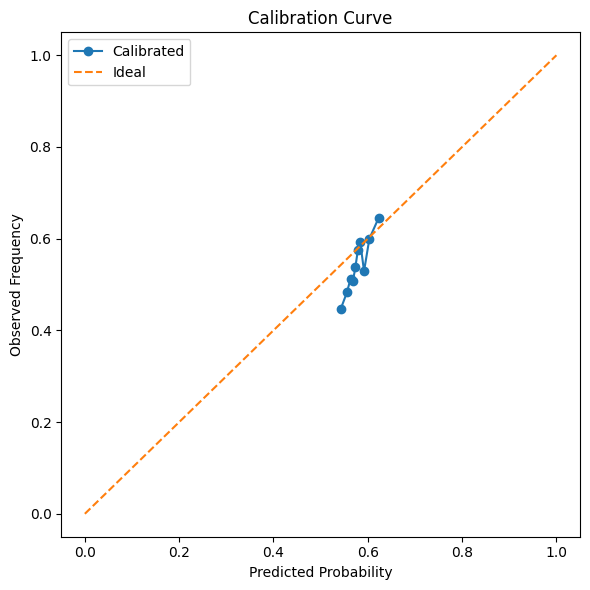

In [17]:
from sklearn.calibration import calibration_curve
import joblib

try:
    model = joblib.load(train_out['best_model_path'])
    calibrator = joblib.load(train_out['calibration_path'])
    ds = pd.read_parquet(DATA_DIR / 'ml_dataset.parquet')

    feature_cols = report.get('feature_columns', [c for c in ds.columns if c not in {'date','timestamp','side','y','pnl','trade_return','costs'}])
    X_all = ds[feature_cols]
    y_all = ds['y'].astype(int)

    if hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X_all), dtype=float)
    else:
        p_raw = np.asarray(model.predict_proba(X_all)[:, 1], dtype=float)
        p_raw = np.clip(p_raw, 1e-8, 1 - 1e-8)
        raw_scores = np.log(p_raw / (1 - p_raw))

    p_cal = calibrator.predict_proba(raw_scores)
    frac_pos, mean_pred = calibration_curve(y_all, p_cal, n_bins=10, strategy='quantile')

    plt.figure(figsize=(6, 6))
    plt.plot(mean_pred, frac_pos, marker='o', label='Calibrated')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal')
    plt.title('Calibration Curve')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Calibration curve unavailable:', exc)


### 7.5 Ranking Power (Decile Test)

Why this matters: for sizing overlays, we care that higher `p_good` buckets have better realized return profile than lower buckets.

,decile,n,mean_trade_return,win_rate,p_good_mean
0,0,121,-0.000356,0.446281,0.542455
1,1,120,0.000087,0.483333,0.555935
2,2,121,0.000130,0.512397,0.563327
3,3,120,0.000047,0.508333,0.568594
4,4,121,0.000278,0.537190,0.573632
5,5,120,0.000060,0.575000,0.578890
6,6,120,0.000319,0.591667,0.584074
7,7,121,0.000080,0.528926,0.592031
8,8,120,0.000137,0.600000,0.603363
9,9,121,0.000360,0.644628,0.622727


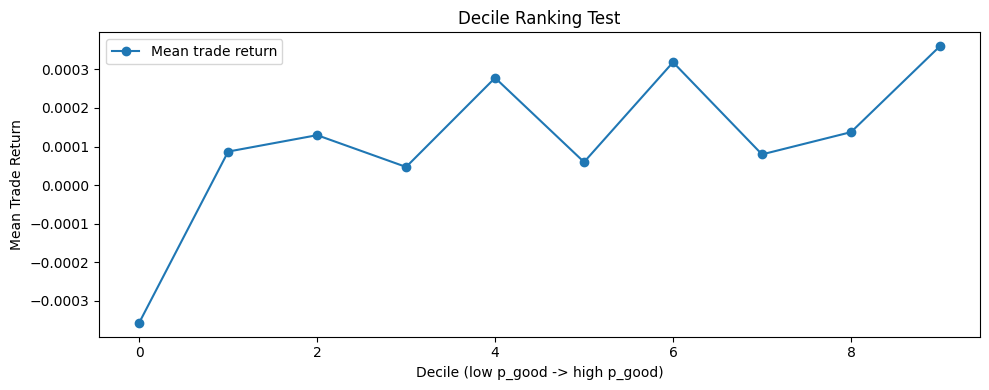

In [18]:
try:
    ds = pd.read_parquet(DATA_DIR / 'ml_dataset.parquet').copy()
    if 'trade_return' not in ds.columns:
        ds['trade_return'] = ds['y'].map({1: 1.0, 0: -1.0})

    feature_cols = report.get('feature_columns', [c for c in ds.columns if c not in {'date','timestamp','side','y','pnl','trade_return','costs'}])
    X_all = ds[feature_cols]

    if 'model' not in locals() or 'calibrator' not in locals():
        model = joblib.load(train_out['best_model_path'])
        calibrator = joblib.load(train_out['calibration_path'])

    if hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X_all), dtype=float)
    else:
        p_raw = np.asarray(model.predict_proba(X_all)[:, 1], dtype=float)
        p_raw = np.clip(p_raw, 1e-8, 1 - 1e-8)
        raw_scores = np.log(p_raw / (1 - p_raw))

    ds['p_good'] = calibrator.predict_proba(raw_scores)
    ds['decile'] = pd.qcut(ds['p_good'], 10, labels=False, duplicates='drop')

    decile_stats = (
        ds.groupby('decile', as_index=False)
        .agg(
            n=('trade_return', 'size'),
            mean_trade_return=('trade_return', 'mean'),
            win_rate=('y', 'mean'),
            p_good_mean=('p_good', 'mean'),
        )
    )
    display(decile_stats)

    plt.figure(figsize=(10, 4))
    plt.plot(decile_stats['decile'], decile_stats['mean_trade_return'], marker='o', label='Mean trade return')
    plt.title('Decile Ranking Test')
    plt.xlabel('Decile (low p_good -> high p_good)')
    plt.ylabel('Mean Trade Return')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Decile test unavailable:', exc)


## 8) ML-filtered backtest

This section is now best read as an **exploratory research block**, not the canonical serious-path result.

What it does:
- probes a hard-filter version for diagnostics only;
- runs a conservative soft-sizing overlay with neutral-zone and regime stabilizers;
- compares those exploratory variants against the same baseline strategy.

What it is **not**:
- it is not the current default score-forward method used for final selection;
- it is not the realism-adjusted winner documented later in notebooks 3 and 4.

Use this section to understand earlier ML-integration ideas. For the current realistic selection path, rely on:
- notebook 3 for realistic soft / hybrid-stop improvements;
- notebook 4 for whole-timeline and holdout overfitting checks;
- `python -m src.cli backtest_ml_scoreforward` for the code-path summary.


### Section 8 Overlay Controls

This notebook block keeps the earlier exploratory stabilizers:
- **neutral zone** around the middle probability region, so many noisy candidates keep `size_mult=1.0`;
- **regime overlay** enabled in this notebook experiment, to avoid resizing aggressively when recent behavior is weak.

That makes this section useful for research diagnostics, but it also means the numbers here should not be read as the final active deployment configuration.


### 8.1 Prepare Candidate Probabilities

Load model-driven candidate probabilities (`p_good`) from baseline candidate events.

In [19]:
import json
from src.backtest_ml_filter import run_ml_filtered_backtest

probe_out = run_ml_filtered_backtest(
    bars_ind,
    flip_reject_mode="hold",
    filter_mode="entry_only",
    allocation_mode="hard_filter",
)
decisions = probe_out["candidate_decisions"].dropna(subset=["p_good"]).copy()
if decisions.empty:
    raise RuntimeError("No candidate decisions with p_good available for threshold tuning.")

display(decisions[["timestamp", "p_good"]].head())
print("candidate rows:", len(decisions))


,timestamp,p_good
0,2021-01-06 10:30:00-05:00,0.611377
1,2021-01-06 11:00:00-05:00,0.574722
2,2021-01-06 11:30:00-05:00,0.575347
3,2021-01-06 13:30:00-05:00,0.595063
4,2021-01-06 14:00:00-05:00,0.606749


candidate rows: 4074


### 8.2 Hard Filter Sweep (Diagnostic Only)

This is a reference test to show how strict trade skipping behaves across thresholds.

In [20]:
cfg = load_config()
models_dir = cfg.data_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

quantiles = [0.50, 0.55, 0.60, 0.65, 0.70]
hard_results, hard_runs = [], {}

for q in quantiles:
    thr = float(decisions["p_good"].quantile(q))
    thr_file = models_dir / f"selected_threshold_q{int(q*100)}.json"
    thr_file.write_text(json.dumps({"threshold": thr}, indent=2), encoding="utf-8")

    out_q = run_ml_filtered_backtest(
        bars_ind,
        threshold_path=thr_file,
        flip_reject_mode="hold",
        filter_mode="entry_only",
        allocation_mode="hard_filter",
    )
    m = out_q["metrics"]
    hard_results.append(
        {
            "mode": "hard_filter",
            "quantile": q,
            "threshold": thr,
            "accept_rate": float(out_q["candidate_decisions"]["accepted"].mean()) if len(out_q["candidate_decisions"]) else 0.0,
            "final_equity": float(m.get("final_equity", float("nan"))),
            "sharpe": float(m.get("sharpe", float("nan"))),
            "max_drawdown": float(m.get("max_drawdown", float("nan"))),
            "trades_count": int(m.get("trades_count", 0)),
        }
    )
    hard_runs[q] = out_q

hard_df = pd.DataFrame(hard_results).sort_values(["sharpe", "final_equity"], ascending=False).reset_index(drop=True)
hard_best = hard_df.iloc[0]
best_q = float(hard_best["quantile"])
best_thr = float(hard_best["threshold"])
hard_best_out = hard_runs[best_q]

display(hard_df)
print(f"Selected hard-filter quantile: {best_q:.2f}")
print(f"Selected hard-filter threshold: {best_thr:.6f}")


,mode,quantile,threshold,accept_rate,final_equity,sharpe,max_drawdown,trades_count
0,hard_filter,0.550000,0.576866,0.415857,"207,134.994100",1.244106,-0.165126,813
1,hard_filter,0.500000,0.574712,0.466341,"209,496.774600",1.244001,-0.176981,859
2,hard_filter,0.600000,0.579032,0.366858,"195,109.157600",1.156211,-0.157830,766
3,hard_filter,0.650000,0.581246,0.315256,"173,904.631700",0.997241,-0.175799,715
4,hard_filter,0.700000,0.583253,0.268372,"162,436.692900",0.903498,-0.170202,661


Selected hard-filter quantile: 0.55
Selected hard-filter threshold: 0.576866


### 8.3 Persist Probability Anchors for Soft Sizing

Save threshold and quantile anchors (`q20/q40/q60/q80`) used by the production sizing map.

In [21]:
q20 = float(decisions["p_good"].quantile(0.20))
q40 = float(decisions["p_good"].quantile(0.40))
q60 = float(decisions["p_good"].quantile(0.60))
q80 = float(decisions["p_good"].quantile(0.80))

selected_threshold_path = models_dir / "selected_threshold.json"
selected_threshold_path.write_text(
    json.dumps(
        {
            "threshold": best_thr,
            "source": "notebook_quantile_sweep",
            "quantile": best_q,
            "prob_q20": q20,
            "prob_q40": q40,
            "prob_q60": q60,
            "prob_q80": q80,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Soft-size q20/q40/q60/q80: {q20:.6f}, {q40:.6f}, {q60:.6f}, {q80:.6f}")
print("Saved:", selected_threshold_path)


Soft-size q20/q40/q60/q80: 0.561071, 0.570459, 0.579032, 0.588873
Saved: data/models/selected_threshold.json


### 8.4 Run Exploratory Soft Sizing

Run the earlier notebook soft-sizing reference and compare it with baseline and the hard-filter diagnostic.

This cell is intentionally kept for research continuity. It is not the current serious-path default documented in notebooks 3 and 4.


In [22]:
soft_out = run_ml_filtered_backtest(
    bars_ind,
    threshold_path=selected_threshold_path,
    flip_reject_mode="hold",
    filter_mode="entry_only",
    allocation_mode="soft_size",
    size_floor=0.85,
    size_cap=1.15,
    neutral_zone=True,
    regime_overlay=True,
    regime_lookback_months=6,
    regime_min_trades=80,
)

soft_metrics = soft_out["metrics"]
hard_metrics = hard_best_out["metrics"]
base_metrics = hard_best_out["baseline_summary"]

mode_compare = pd.DataFrame(
    [
        {
            "mode": "baseline",
            "final_equity": float(base_metrics.get("final_equity", float("nan"))),
            "sharpe": float(base_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(base_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(base_metrics.get("trades_count", 0)),
        },
        {
            "mode": "hard_filter_best",
            "final_equity": float(hard_metrics.get("final_equity", float("nan"))),
            "sharpe": float(hard_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(hard_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(hard_metrics.get("trades_count", 0)),
        },
        {
            "mode": "soft_size",
            "final_equity": float(soft_metrics.get("final_equity", float("nan"))),
            "sharpe": float(soft_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(soft_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(soft_metrics.get("trades_count", 0)),
            "avg_size_mult": float(soft_metrics.get("avg_size_mult", 1.0)),
            "overlay_enabled_rate": float(soft_metrics.get("overlay_enabled_rate", 0.0)),
        },
    ]
)

# production selection
selected_mode = "soft_size"
ml_out = soft_out
ml_equity = ml_out['equity_curve'].copy()
ml_trades = ml_out['trades'].copy()
ml_metrics = ml_out['metrics']
comparison = ml_out['comparison'].copy()

display(mode_compare)
display(comparison)


,mode,final_equity,sharpe,max_drawdown,trades_count,avg_size_mult,overlay_enabled_rate
0,baseline,"219,903.083900",1.125263,-0.131538,1205,NaN,NaN
1,hard_filter_best,"207,134.994100",1.244106,-0.165126,813,NaN,NaN
2,soft_size,"228,631.152100",1.176291,-0.131301,1205,1.005530,0.604979


,baseline,ml_filter,delta
final_equity,"219,903.083900","228,631.152100","8,728.068200"
sharpe,1.125263,1.176291,0.051028
cagr_ish,0.171437,0.180628,0.009191
max_drawdown,-0.131538,-0.131301,0.000237
trades_count,"1,205.000000","1,205.000000",0.000000
turnover,"6,350.015326","6,367.836609",17.821283
total_costs,"9,636.282000","10,099.971000",463.689000


### 8.5 Save Outputs

Write the selected notebook outputs back to `DATA_DIR` using the same file conventions as the CLI.

Because this section is exploratory, treat these outputs as notebook artifacts rather than the canonical final-method cache.


In [23]:
ml_equity.to_parquet(DATA_DIR / 'ml_equity_curve.parquet', index=False)
ml_trades.to_parquet(DATA_DIR / 'ml_trades.parquet', index=False)
comparison.to_parquet(DATA_DIR / 'ml_vs_baseline.parquet', index=True)
if not ml_out['candidate_decisions'].empty:
    ml_out['candidate_decisions'].to_parquet(DATA_DIR / 'ml_candidate_decisions.parquet', index=False)

with open(DATA_DIR / 'ml_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(ml_metrics, f, indent=2, default=str)
with open(DATA_DIR / 'ml_vs_baseline.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'baseline_summary': ml_out['baseline_summary'],
            'ml_metrics': ml_metrics,
            'comparison': comparison.to_dict(orient='index'),
            'selected_threshold': best_thr,
            'selected_quantile': best_q,
            'threshold_sweep': hard_results,
            'mode_compare': mode_compare.to_dict(orient='records'),
            'selected_ml_variant': selected_mode,
        },
        f,
        indent=2,
        default=str,
    )

print('Saved ML outputs to DATA_DIR')



Saved ML outputs to DATA_DIR


### 8.6 Performance validation and interpretation

We look at ML results in this order:
1. **Level**: final equity and CAGR-ish (did we make more money?).
2. **Risk-adjusted quality**: Sharpe and max drawdown (did we improve return per unit risk?).
3. **Consistency through time**: monthly return delta vs baseline (is improvement concentrated in one period?).
4. **Execution footprint**: trades count/turnover/costs (did gains come from hidden over-trading?).
5. **Overlay behavior**: size multipliers and outcome by size bucket (is confidence-based sizing actually informative?).

This helps avoid false confidence from a single headline metric.


In [24]:
# Consolidated summary table used for interpretation
summary_rows = [
    {
        'strategy': 'baseline',
        'final_equity': float(base_metrics.get('final_equity', np.nan)),
        'sharpe': float(base_metrics.get('sharpe', np.nan)),
        'cagr_ish': float(base_metrics.get('cagr_ish', np.nan)),
        'max_drawdown': float(base_metrics.get('max_drawdown', np.nan)),
        'trades_count': float(base_metrics.get('trades_count', np.nan)),
        'turnover': float(base_metrics.get('turnover', np.nan)),
        'total_costs': float(base_metrics.get('total_costs', np.nan)),
    },
    {
        'strategy': 'ml_selected',
        'final_equity': float(ml_metrics.get('final_equity', np.nan)),
        'sharpe': float(ml_metrics.get('sharpe', np.nan)),
        'cagr_ish': float(ml_metrics.get('cagr_ish', np.nan)),
        'max_drawdown': float(ml_metrics.get('max_drawdown', np.nan)),
        'trades_count': float(ml_metrics.get('trades_count', np.nan)),
        'turnover': float(ml_metrics.get('turnover', np.nan)),
        'total_costs': float(ml_metrics.get('total_costs', np.nan)),
        'avg_size_mult': float(ml_metrics.get('avg_size_mult', np.nan)),
        'overlay_enabled_rate': float(ml_metrics.get('overlay_enabled_rate', np.nan)),
    },
]
summary_df = pd.DataFrame(summary_rows).set_index('strategy')
summary_df.loc['delta_ml_minus_base'] = summary_df.loc['ml_selected'] - summary_df.loc['baseline']

display(summary_df)

print('Interpretation tips:')
print('- Prefer ML only if final_equity/CAGR improve without a disproportionate Sharpe or drawdown deterioration.')
print('- avg_size_mult near 1.0 means the overlay is mild; far from 1.0 means stronger active sizing.')
print('- If turnover and costs rise too much, check whether net gains still justify complexity.')


,final_equity,sharpe,cagr_ish,max_drawdown,trades_count,turnover,total_costs,avg_size_mult,overlay_enabled_rate
strategy,,,,,,,,,
baseline,"219,903.083900",1.125263,0.171437,-0.131538,"1,205.000000","6,350.015326","9,636.282000",NaN,NaN
ml_selected,"228,631.152100",1.176291,0.180628,-0.131301,"1,205.000000","6,367.836609","10,099.971000",1.005530,0.604979
delta_ml_minus_base,"8,728.068200",0.051028,0.009191,0.000237,0.000000,17.821283,463.689000,NaN,NaN


Interpretation tips:
- Prefer ML only if final_equity/CAGR improve without a disproportionate Sharpe or drawdown deterioration.
- avg_size_mult near 1.0 means the overlay is mild; far from 1.0 means stronger active sizing.
- If turnover and costs rise too much, check whether net gains still justify complexity.


### 8.7 Risk and path diagnostics

Why these plots:
- **Equity curve** shows absolute wealth evolution.
- **Drawdown curve** shows pain profile and recovery speed.
- **Rolling relative return** highlights time blocks where ML helps/hurts versus baseline.


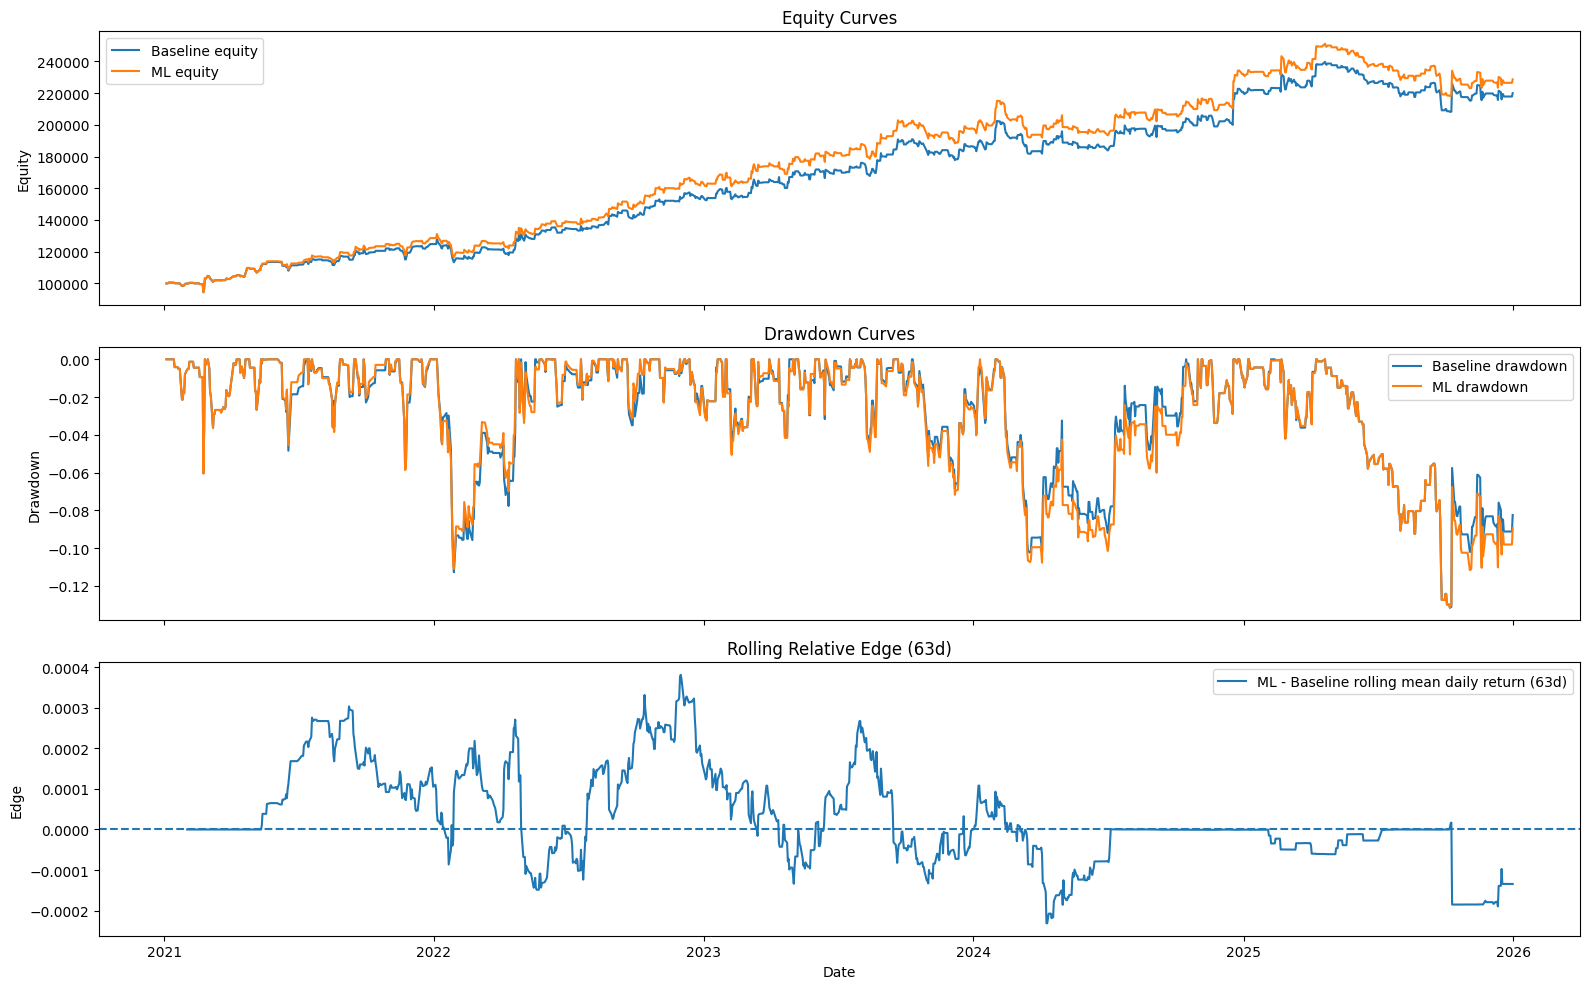

In [25]:
eq_base = baseline_equity.copy()
eq_ml = ml_equity.copy()

for df in (eq_base, eq_ml):
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)

# Drawdown series
def drawdown_series(equity: pd.Series) -> pd.Series:
    running_max = equity.cummax()
    return equity / running_max - 1.0

eq_base['drawdown'] = drawdown_series(eq_base['equity'])
eq_ml['drawdown'] = drawdown_series(eq_ml['equity'])

# Rolling relative edge (63 trading days ~ 3 months)
ret_base = eq_base.set_index('date')['daily_return']
ret_ml = eq_ml.set_index('date')['daily_return']
ret_cmp = pd.concat([ret_base.rename('base'), ret_ml.rename('ml')], axis=1).dropna()
ret_cmp['edge'] = ret_cmp['ml'] - ret_cmp['base']
ret_cmp['edge_63d_mean'] = ret_cmp['edge'].rolling(63, min_periods=20).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
axes[0].plot(eq_base['date'], eq_base['equity'], label='Baseline equity')
axes[0].plot(eq_ml['date'], eq_ml['equity'], label='ML equity')
axes[0].set_title('Equity Curves')
axes[0].set_ylabel('Equity')
axes[0].legend()

axes[1].plot(eq_base['date'], eq_base['drawdown'], label='Baseline drawdown')
axes[1].plot(eq_ml['date'], eq_ml['drawdown'], label='ML drawdown')
axes[1].set_title('Drawdown Curves')
axes[1].set_ylabel('Drawdown')
axes[1].legend()

axes[2].plot(ret_cmp.index, ret_cmp['edge_63d_mean'], label='ML - Baseline rolling mean daily return (63d)')
axes[2].axhline(0.0, linestyle='--')
axes[2].set_title('Rolling Relative Edge (63d)')
axes[2].set_ylabel('Edge')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()


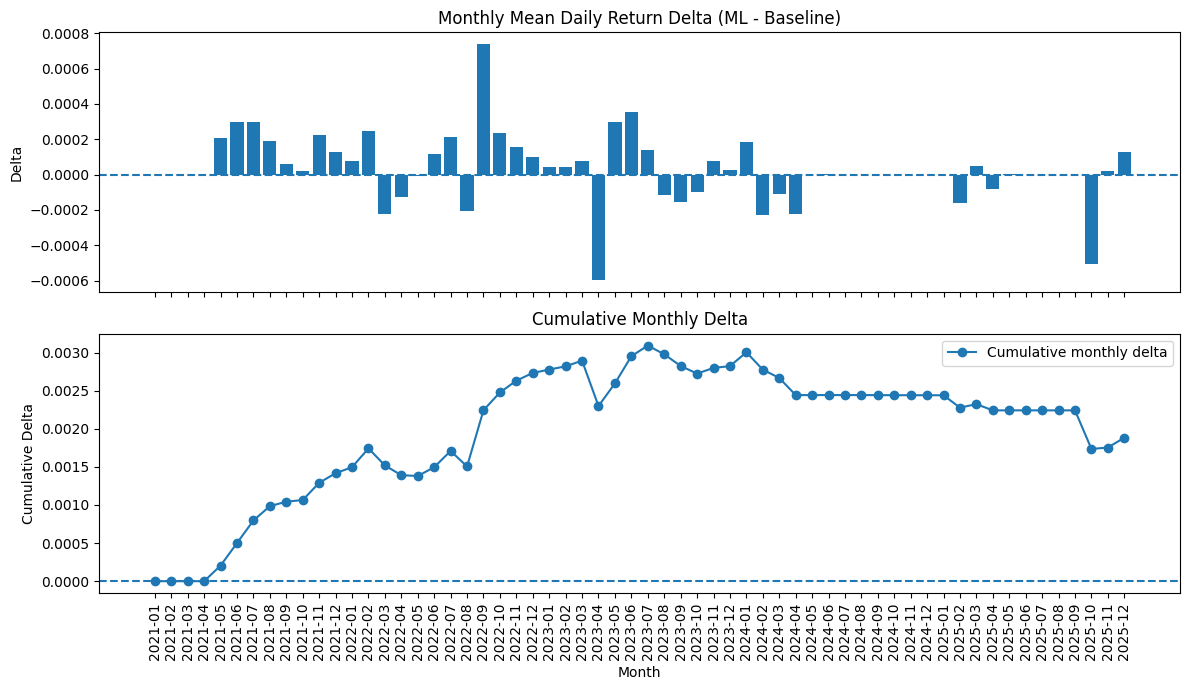

Months with strongest ML underperformance:


,month,daily_return_base,daily_return_ml,delta,cum_delta
27,2023-04,0.000517,-0.000079,-0.000595,0.002299
57,2025-10,0.001857,0.001351,-0.000506,0.001735
37,2024-02,-0.001615,-0.001843,-0.000228,0.002777
39,2024-04,0.003054,0.002829,-0.000225,0.002443
14,2022-03,0.000722,0.000498,-0.000224,0.001519
19,2022-08,0.002781,0.002577,-0.000204,0.001506


In [26]:
# Monthly consistency: where ML adds or subtracts value
m_base = eq_base.assign(month=eq_base['date'].dt.to_period('M').astype(str)).groupby('month', as_index=False)['daily_return'].mean()
m_ml = eq_ml.assign(month=eq_ml['date'].dt.to_period('M').astype(str)).groupby('month', as_index=False)['daily_return'].mean()
m_cmp = m_base.merge(m_ml, on='month', suffixes=('_base', '_ml'))
m_cmp['delta'] = m_cmp['daily_return_ml'] - m_cmp['daily_return_base']
m_cmp['cum_delta'] = m_cmp['delta'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(m_cmp['month'], m_cmp['delta'])
axes[0].axhline(0.0, linestyle='--')
axes[0].set_title('Monthly Mean Daily Return Delta (ML - Baseline)')
axes[0].set_ylabel('Delta')

axes[1].plot(m_cmp['month'], m_cmp['cum_delta'], marker='o', label='Cumulative monthly delta')
axes[1].axhline(0.0, linestyle='--')
axes[1].set_title('Cumulative Monthly Delta')
axes[1].set_ylabel('Cumulative Delta')
axes[1].set_xlabel('Month')
axes[1].legend()

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Months with strongest ML underperformance:')
display(m_cmp.nsmallest(6, 'delta'))


### 8.8 Overlay behavior diagnostics

These checks answer: **is ML confidence being translated into sensible sizing?**
- If larger `size_mult` buckets have better realized PnL (or at least not worse), ranking is useful.
- If all buckets look random/noisy, sizing map is likely overfitting or too weak.


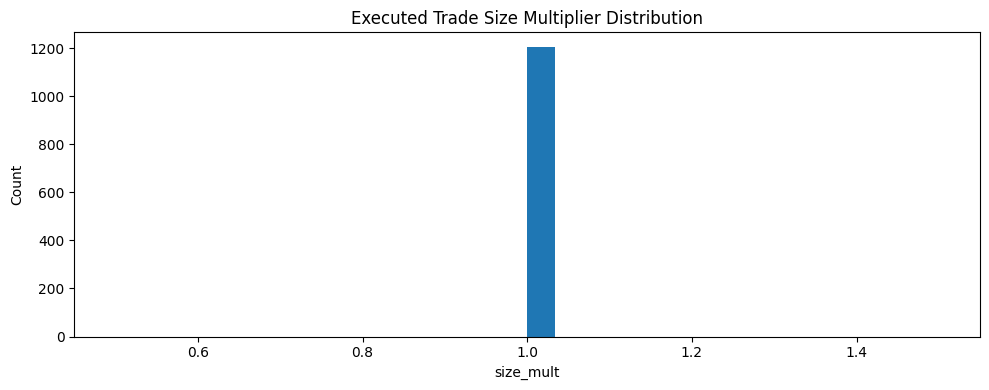

In [27]:
dec = ml_out['candidate_decisions'].copy()
tr = ml_out['trades'].copy()

if dec.empty or tr.empty:
    print('No candidate decisions or trades available for overlay diagnostics.')
else:
    dec['timestamp'] = pd.to_datetime(dec['timestamp'])
    tr['entry_timestamp'] = pd.to_datetime(tr['entry_timestamp'])
    tr['exit_timestamp'] = pd.to_datetime(tr['exit_timestamp'])
    tr['win'] = (tr['pnl'] > 0).astype(int)

    # Attach decision-time ML fields to each executed trade
    join_cols = [c for c in ['timestamp', 'p_good', 'size_mult'] if c in dec.columns]
    eval_df = tr.merge(dec[join_cols], left_on='entry_timestamp', right_on='timestamp', how='left')
    eval_df['size_mult'] = eval_df.get('size_mult', pd.Series(index=eval_df.index, dtype=float)).fillna(1.0)

    # A) size multiplier distribution
    plt.figure(figsize=(10, 4))
    plt.hist(eval_df['size_mult'], bins=30)
    plt.title('Executed Trade Size Multiplier Distribution')
    plt.xlabel('size_mult')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


   


## 9) Alpaca Live Data and Paper-Trading Demo

This section is additive only. It uses the separate live websocket path and does not change any backtest, score-forward, or notebook 3/4 metrics.

What it does:
- seeds recent 1-minute SPY history so the live indicators are defined before streaming starts
- opens the Alpaca websocket stream for fresh minute bars
- renders a live chart with `close`, `UB`, `LB`, and `VWAP`
- optionally attaches the Alpaca paper broker if `.env` points to the paper endpoint

Notes:
- use `ALPACA_BASE_URL=https://paper-api.alpaca.markets`
- use `ALPACA_LIVE_FEED=iex` unless you have SIP entitlement
- the first runtime state may be `warming_live_stream` until the first fresh websocket bar arrives


In [ ]:
import matplotlib.pyplot as plt
from src.live_alpaca import (
    AlpacaLiveMarketData,
    AlpacaPaperBroker,
    compute_live_strategy_snapshot,
    notebook_live_monitor,
    render_live_strategy_chart,
)

LIVE_SYMBOL = 'SPY'
LIVE_HISTORY_DAYS = 1
LIVE_REFRESH_SECONDS = 5
LIVE_DURATION_SECONDS = 300

live_data = AlpacaLiveMarketData(symbol=LIVE_SYMBOL, history_business_days=LIVE_HISTORY_DAYS)
try:
    paper_broker = AlpacaPaperBroker()
    print('Paper broker ready:', paper_broker.paper)
except ValueError as exc:
    paper_broker = None
    print(f'Paper broker unavailable: {exc}')


In [ ]:
# Seed recent history so UB/LB/VWAP are available before the websocket starts.
live_seed = live_data.seed_history()
live_enriched = live_data.enriched_bars()
live_snapshot = compute_live_strategy_snapshot(live_enriched)
display(pd.DataFrame([live_snapshot]))
fig, _ = render_live_strategy_chart(live_enriched, symbol=LIVE_SYMBOL, title_suffix='(seeded history)')
plt.show()


### 9.1 Start the live streams

Run the next cell once to start the background websocket threads for:
- live market bars
- optional paper trade updates

If the seeded bar is the latest row at start-up, the first state will be informational only and will not trigger a trade.


In [ ]:
live_data.start()
if paper_broker is not None:
    paper_broker.start_trade_updates()
print('Live bar stream running:', live_data.is_running)
print('Trade update stream running:', False if paper_broker is None else paper_broker.is_streaming)


In [ ]:
# Live-updating chart. Interrupt the cell to stop the monitor loop.
notebook_live_monitor(
    live_data,
    broker=paper_broker,
    refresh_seconds=LIVE_REFRESH_SECONDS,
    duration_seconds=LIVE_DURATION_SECONDS,
    stop_on_exit=False,
)


In [ ]:
# Optional cleanup and paper-order examples. Run manually, one line at a time.
# from src.core.types import Side
# if paper_broker is not None:
#     paper_broker.submit_market_order(LIVE_SYMBOL, Side.LONG, qty=1)
#     paper_broker.flatten_symbol(LIVE_SYMBOL)
#     paper_broker.latest_trade_updates()
# live_data.stop()
# if paper_broker is not None:
#     paper_broker.stop_trade_updates()
